In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
movies = pd.read_csv('Movie.csv')

In [4]:
movies.head()

,userId,movie,rating
0,3,Toy Story (1995),4.0
1,6,Toy Story (1995),5.0
2,8,Toy Story (1995),4.0
3,10,Toy Story (1995),4.0
4,11,Toy Story (1995),4.5


In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8992 entries, 0 to 8991
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   userId  8992 non-null   int64  
 1   movie   8992 non-null   object 
 2   rating  8992 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 210.9+ KB


In [6]:
movies['movie'].unique()

array(['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)',
       'Waiting to Exhale (1995)', 'Father of the Bride Part II (1995)',
       'Heat (1995)', 'Sabrina (1995)', 'Tom and Huck (1995)',
       'Sudden Death (1995)', 'GoldenEye (1995)'], dtype=object)

In [7]:
movies['movie'].nunique()

10

In [8]:
movies.userId.nunique()

4081

### What ratings are users giving?

In [11]:
ratings = movies.rating.value_counts()
ratings

rating
3.0    2736
4.0    2660
5.0    1394
3.5     679
2.0     542
4.5     374
2.5     277
1.0     212
1.5      61
0.5      57
Name: count, dtype: int64

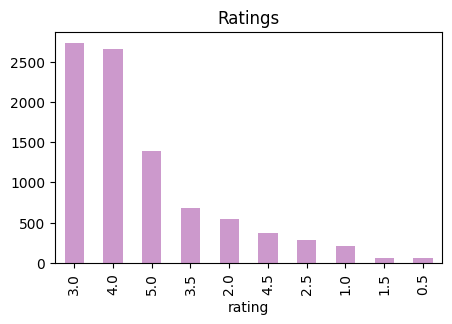

In [18]:
plt.figure(figsize=(5,3))
ratings.plot(kind='bar', color='purple', alpha=0.4, title='Ratings')
plt.show()

#### What is the average rating for each movie?

In [23]:
avg_rating =  movies.groupby('movie').agg('mean')['rating'].sort_values(ascending=False)
avg_rating

movie
Toy Story (1995)                      3.959323
Heat (1995)                           3.836508
GoldenEye (1995)                      3.427003
Sabrina (1995)                        3.381429
Tom and Huck (1995)                   3.352564
Jumanji (1995)                        3.268398
Grumpier Old Men (1995)               3.186861
Father of the Bride Part II (1995)    3.143836
Sudden Death (1995)                   3.017327
Waiting to Exhale (1995)              3.000000
Name: rating, dtype: float64

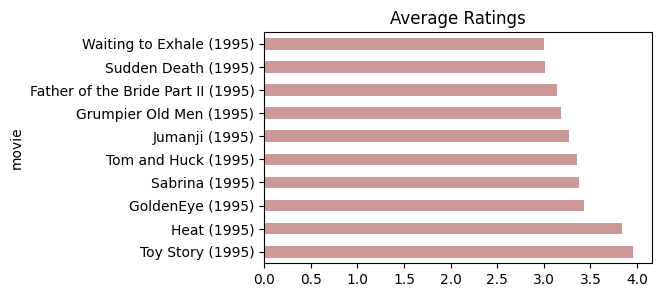

In [24]:
plt.figure(figsize=(5,3))
avg_rating.plot(kind='barh', color='maroon', alpha=0.4, title='Average Ratings')
plt.show()

#### How many users have rated each movie?

In [31]:
popular_movies = movies.groupby('movie').agg('count')['rating'].sort_values(ascending=False)
popular_movies

movie
Toy Story (1995)                      2569
GoldenEye (1995)                      1548
Heat (1995)                           1260
Jumanji (1995)                        1155
Sabrina (1995)                         700
Grumpier Old Men (1995)                685
Father of the Bride Part II (1995)     657
Sudden Death (1995)                    202
Waiting to Exhale (1995)               138
Tom and Huck (1995)                     78
Name: rating, dtype: int64

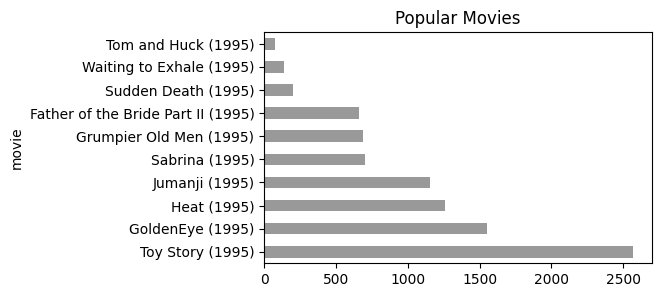

In [33]:
plt.figure(figsize=(5,3))
popular_movies.plot(kind='barh', color='black', alpha=0.4, title='Popular Movies')
plt.show()

### User_Movie_Matrix

In [34]:
user_movie_matrix = pd.pivot_table(data=movies, columns='movie', index='userId', values='rating')
user_movie_matrix

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
1,NaN,NaN,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
4,NaN,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7115,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7116,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
7117,NaN,3.0,4.0,5.0,NaN,3.0,1.0,NaN,4.0,NaN


In [36]:
user_movie_matrix.fillna(0, inplace=True)

In [37]:
user_movie_matrix

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
1,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
4,0.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
7115,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7116,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
7117,0.0,3.0,4.0,5.0,0.0,3.0,1.0,0.0,4.0,0.0


### User User Similarity matrix

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
user_sim_matrix = cosine_similarity(user_movie_matrix)
user_sim_matrix

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.55337157],
       [0.        , 1.        , 0.        , ..., 0.45883147, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.45883147, 1.        ,
        0.62254302],
       ...,
       [0.        , 0.45883147, 0.45883147, ..., 1.        , 0.45883147,
        0.47607054],
       [0.        , 0.        , 1.        , ..., 0.45883147, 1.        ,
        0.62254302],
       [0.55337157, 0.        , 0.62254302, ..., 0.47607054, 0.62254302,
        1.        ]])

In [40]:
np.fill_diagonal(user_sim_matrix,0)

In [41]:
user_sim_matrix

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.55337157],
       [0.        , 0.        , 0.        , ..., 0.45883147, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.45883147, 1.        ,
        0.62254302],
       ...,
       [0.        , 0.45883147, 0.45883147, ..., 0.        , 0.45883147,
        0.47607054],
       [0.        , 0.        , 1.        , ..., 0.45883147, 0.        ,
        0.62254302],
       [0.55337157, 0.        , 0.62254302, ..., 0.47607054, 0.62254302,
        0.        ]])

In [42]:
user_sim_df =  pd.DataFrame(data=user_sim_matrix, columns=movies.userId.unique(), index=movies.userId.unique())
user_sim_df

,3,6,8,10,11,12,13,14,16,19,...,6975,6979,6993,7030,7031,7044,7070,7080,7087,7105
3,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.707107,0.000000,0.000000,0.000000,0.000000,0.000000,0.553372
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.390567,0.707107,0.615457,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.458831,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.650945,0.000000,0.492366,1.000000,0.874157,...,0.000000,1.000000,0.000000,0.707107,0.000000,0.000000,0.752577,0.458831,1.000000,0.622543
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.615457,0.000000,0.388514,...,0.800000,0.000000,0.000000,0.000000,0.989949,0.000000,0.000000,0.619422,0.000000,0.000000
11,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.707107,0.000000,0.000000,0.000000,0.000000,0.000000,0.553372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7044,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.658505,0.000000,0.000000,0.000000
7070,0.000000,0.000000,0.752577,0.000000,0.000000,0.489886,0.000000,0.370543,0.752577,0.657870,...,0.000000,0.752577,0.000000,0.532152,0.000000,0.658505,0.000000,0.345306,0.752577,0.468511
7080,0.000000,0.458831,0.458831,0.619422,0.000000,0.701884,0.567775,0.889532,0.458831,0.568212,...,0.344124,0.458831,0.000000,0.324443,0.648886,0.000000,0.345306,0.000000,0.458831,0.476071
7087,0.000000,0.000000,1.000000,0.000000,0.000000,0.650945,0.000000,0.492366,1.000000,0.874157,...,0.000000,1.000000,0.000000,0.707107,0.000000,0.000000,0.752577,0.458831,0.000000,0.622543


#### Make recommendation for user 11

#### a. Find the first 3 users who are similar to user 11

In [43]:
user = 11

In [44]:
user_sim_df.loc[user]

3       1.000000
6       0.000000
8       0.000000
10      0.000000
11      0.000000
          ...   
7044    0.000000
7070    0.000000
7080    0.000000
7087    0.000000
7105    0.553372
Name: 11, Length: 4081, dtype: float64

In [47]:
sim_users = user_sim_df.loc[user].sort_values(ascending=False)[:3]
sim_users

3      1.0
497    1.0
743    1.0
Name: 11, dtype: float64

In [50]:
sim_usr_lst = sim_users.index.to_list()
sim_usr_lst

[3, 497, 743]

#### Find the movies that are highly rated by the simialr users

In [52]:
sim_usr_ratings = user_movie_matrix.loc[sim_usr_lst]
sim_usr_ratings

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
497,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
743,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0


In [53]:
sim_usr_ratings.values.argsort()

array([[0, 1, 2, 3, 4, 5, 6, 7, 9, 8],
       [0, 1, 2, 4, 5, 6, 7, 8, 9, 3],
       [1, 2, 3, 5, 6, 7, 8, 9, 0, 4]])

In [57]:
movie_ids = sim_usr_ratings.values.argsort()[:,-1].tolist()
movie_ids

[8, 3, 4]

In [56]:
sim_usr_ratings.columns

Index(['Father of the Bride Part II (1995)', 'GoldenEye (1995)',
       'Grumpier Old Men (1995)', 'Heat (1995)', 'Jumanji (1995)',
       'Sabrina (1995)', 'Sudden Death (1995)', 'Tom and Huck (1995)',
       'Toy Story (1995)', 'Waiting to Exhale (1995)'],
      dtype='object', name='movie')

In [59]:
sim_usr_ratings.columns[movie_ids]

Index(['Toy Story (1995)', 'Heat (1995)', 'Jumanji (1995)'], dtype='object', name='movie')

#### These are the movies we will recommend to user 11